# 03 — p16 / Senescence Characterization

Quantifies p16 (CDKN2A) expression and senescence burden across all TCGA samples.

**Analyses:**
1. CDKN2A mRNA expression pan-cancer
2. ssGSEA senescence signature scores (MSigDB sets via `gseapy`)
3. SASP gene signature score
4. CDKN2A genomic status (CNA + mutation from cBioPortal)

**Output:** `../data/sample_senescence.parquet`

In [1]:
import sys
sys.path.insert(0, "../src")

import json
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
from pathlib import Path

from signatures import SASP_GENES, SENESCENCE_EFFECTORS, MSIGDB_SETS
from utils import log2tpm, signature_score

DATA = Path("../data")
FIGURES = Path("../figures")
sns.set_theme(style="whitegrid", font_scale=1.1)

## 1. Load Senescence-Relevant Genes from Expression Matrix

In [2]:
import urllib.request as _urllib_request
import json as _json_nb

from signatures import SENESCENCE_EXPRESSION_MARKERS

MSIGDB_CACHE = DATA / "msigdb_genesets.json"

def _fetch_or_load_msigdb(set_name: str) -> list[str]:
    """Load from local cache if available, otherwise fetch from MSigDB web."""
    if MSIGDB_CACHE.exists():
        _cached = _json_nb.loads(MSIGDB_CACHE.read_text())
        if set_name in _cached:
            return _cached[set_name]
    url = (
        f"https://www.gsea-msigdb.org/gsea/msigdb/download_geneset.jsp"
        f"?geneSetName={set_name}&fileType=txt"
    )
    req = _urllib_request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with _urllib_request.urlopen(req, timeout=30) as r:
        lines = r.read().decode().strip().splitlines()
    genes = [l.strip() for l in lines[2:] if l.strip()]
    print(f"  Fetched from web: {set_name} ({len(genes)} genes)")
    return genes

# Collect all genes needed from the expression matrix
_msigdb_genes: list[str] = []
for _msig_id in ["FRIDMAN_SENESCENCE_UP", "REACTOME_CELLULAR_SENESCENCE",
                  "SAUL_SEN_MAYO", "HALLMARK_P53_PATHWAY",
                  "GOBP_CELLULAR_SENESCENCE", "FRIDMAN_SENESCENCE_DN"]:
    try:
        _msigdb_genes.extend(_fetch_or_load_msigdb(_msig_id))
        print(f"  Loaded {_msig_id}")
    except Exception as e:
        print(f"  Warning: could not load {_msig_id}: {e}")

_hallmark_genes: list[str] = []
try:
    _hall_lib = gp.get_library("MSigDB_Hallmark_2020", organism="Human")
    for _hall_name in ["Interferon Gamma Response", "Inflammatory Response",
                       "TNF-alpha Signaling via NF-kB"]:
        _hallmark_genes.extend(_hall_lib.get(_hall_name, []))
except Exception as e:
    print(f"  Warning: could not fetch Hallmark sets: {e}")

from signatures import SASP_SUPPRESSIVE, SENESCENCE_MINIMAL_SCORE

TARGET_GENES = list(set(
    SASP_GENES + SENESCENCE_EFFECTORS + SENESCENCE_EXPRESSION_MARKERS
    + SASP_SUPPRESSIVE + SENESCENCE_MINIMAL_SCORE
    + _msigdb_genes + _hallmark_genes
))
print(f"Loading {len(TARGET_GENES)} senescence/immune genes ...")

rows = {}
with gzip.open(DATA / "tcga_pancan_expr.tsv.gz", "rt") as fh:
    samples = fh.readline().strip().split("\t")[1:]
    for line in fh:
        gene = line.split("\t", 1)[0]
        if gene in TARGET_GENES:
            vals = line.strip().split("\t")[1:]
            rows[gene] = [float(v) if v != "NA" else float("nan") for v in vals]

expr = pd.DataFrame(rows, index=samples).T   # genes × samples
print(f"Loaded: {expr.shape}  |  Missing genes: {len(set(TARGET_GENES) - set(expr.index))}")

  Loaded FRIDMAN_SENESCENCE_UP
  Loaded REACTOME_CELLULAR_SENESCENCE
  Loaded SAUL_SEN_MAYO
  Loaded HALLMARK_P53_PATHWAY
  Loaded GOBP_CELLULAR_SENESCENCE
  Loaded FRIDMAN_SENESCENCE_DN


Loading 1055 senescence/immune genes ...


Loaded: (944, 11069)  |  Missing genes: 111


## 2. CDKN2A Expression Pan-Cancer

/var/folders/d7/_l2vycv112b6jl6f1xcyzw7c0000gn/T/ipykernel_46809/1482367273.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


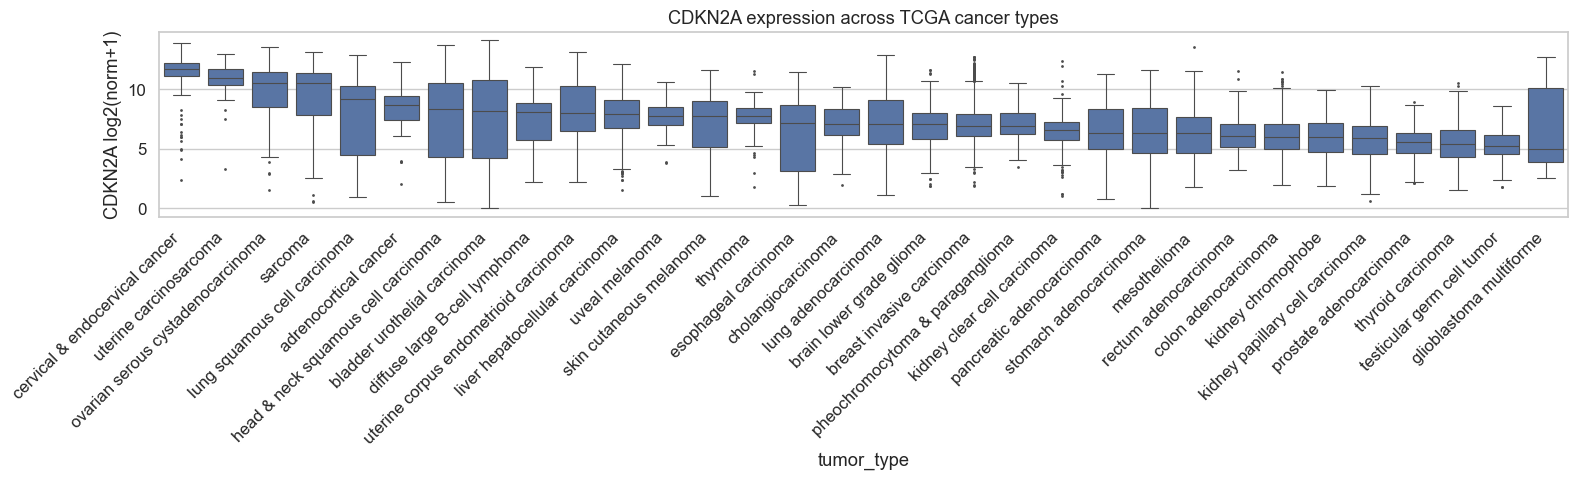

In [3]:
# Load tumor type labels from immune notebook output
immune = pd.read_parquet(DATA / "sample_immune_labels.parquet")

cdkn2a = expr.loc["CDKN2A"].rename("CDKN2A_expr")
df = immune[["tumor_type", "hot_cold"]].join(cdkn2a, how="inner")

# Box plot of CDKN2A by tumor type (sorted by median)
order = (
    df.groupby("tumor_type")["CDKN2A_expr"]
    .median().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df, x="tumor_type", y="CDKN2A_expr", order=order,
            fliersize=1, linewidth=0.8, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylabel("CDKN2A log2(norm+1)")
ax.set_title("CDKN2A expression across TCGA cancer types")
plt.tight_layout()
plt.savefig(FIGURES / "cdkn2a_by_tumor_type.png", dpi=150)
plt.show()

## 3. Senescence Signature Scores via ssGSEA

We use `gseapy.ssgsea` with MSigDB gene sets. This runs on the full expression
matrix (all genes) so we reload a subset efficiently.

> **Runtime note:** ssGSEA on ~11k samples takes ~15–30 minutes.
> A pre-cached parquet is checked first.

In [4]:
import urllib.request

SSGSEA_CACHE = DATA / "ssgsea_senescence_scores.parquet"
MSIGDB_CACHE = DATA / "msigdb_genesets.json"

def fetch_msigdb_geneset(set_name: str) -> list[str]:
    """Fetch gene list — use local cache if available, else fall back to web."""
    if MSIGDB_CACHE.exists():
        cached = json.loads(MSIGDB_CACHE.read_text())
        if set_name in cached:
            return cached[set_name]
    # Fall back to web fetch
    url = (
        f"https://www.gsea-msigdb.org/gsea/msigdb/download_geneset.jsp"
        f"?geneSetName={set_name}&fileType=txt"
    )
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=30) as r:
        lines = r.read().decode().strip().splitlines()
    genes = [l.strip() for l in lines[2:] if l.strip()]
    print(f"  {set_name}: {len(genes)} genes (fetched from web)")
    return genes

if SSGSEA_CACHE.exists():
    print("Loading cached ssGSEA scores ...")
    ssgsea_scores = pd.read_parquet(SSGSEA_CACHE)
else:
    print("Running ssGSEA (this takes ~20–30 min) ...")

    from signatures import SASP_SUPPRESSIVE

    gene_sets = {
        "SASP": SASP_GENES,
        "Senescence_Effectors": SENESCENCE_EFFECTORS,
        "SASP_suppressive": SASP_SUPPRESSIVE,
    }

    for key, msig_id in [("senescence_up",      "FRIDMAN_SENESCENCE_UP"),
                          ("reactome_senescence", "REACTOME_CELLULAR_SENESCENCE"),
                          ("senescence_dn",       "FRIDMAN_SENESCENCE_DN")]:
        try:
            gene_sets[key] = fetch_msigdb_geneset(msig_id)
        except Exception as e:
            print(f"  Warning: could not get {msig_id}: {e}")

    for key, msig_id in [("senmayo",         "SAUL_SEN_MAYO"),
                          ("hallmark_p53",    "HALLMARK_P53_PATHWAY"),
                          ("gobp_senescence", "GOBP_CELLULAR_SENESCENCE")]:
        try:
            gene_sets[key] = fetch_msigdb_geneset(msig_id)
        except Exception as e:
            print(f"  Warning: could not get {msig_id}: {e}")

    hallmark_lib = gp.get_library("MSigDB_Hallmark_2020", organism="Human")
    hallmark_map = {
        "hallmark_ifng": "Interferon Gamma Response",
        "hallmark_inflammatory": "Inflammatory Response",
        "hallmark_tnfa": "TNF-alpha Signaling via NF-kB",
    }
    for key, hall_name in hallmark_map.items():
        if hall_name in hallmark_lib:
            gene_sets[key] = hallmark_lib[hall_name]
        else:
            print(f"  Warning: '{hall_name}' not in Hallmark library")

    print(f"Gene sets to score: {list(gene_sets.keys())}")

    # Log missing genes per set
    expr_genes = set(expr.index)
    for set_name, genes in gene_sets.items():
        missing = [g for g in genes if g not in expr_genes]
        pct_missing = 100 * len(missing) / max(len(genes), 1)
        if pct_missing > 20:
            print(f"  WARNING: {set_name} missing {len(missing)}/{len(genes)} genes ({pct_missing:.0f}%): {missing[:5]}")
        else:
            print(f"  {set_name}: {len(genes)} genes, {len(missing)} missing ({pct_missing:.0f}%)")

    # Warn if any gene set has too few genes after universe filtering
    import warnings
    for gs_name, gs_genes in gene_sets.items():
        available = [g for g in gs_genes if g in expr_genes]
        if len(available) < 5:
            warnings.warn(
                f"Gene set '{gs_name}' has only {len(available)} genes in the expression matrix "
                f"(min_size=5 recommended). ssGSEA scores for this set may be unreliable.",
                UserWarning,
                stacklevel=2,
            )

    ss = gp.ssgsea(
        data=expr,
        gene_sets=gene_sets,
        outdir=None,
        sample_norm_method="rank",
        no_plot=True,
        min_size=5,
    )
    res2d = ss.res2d.drop_duplicates(subset=["Name", "Term"])
    ssgsea_scores = res2d.pivot(index="Name", columns="Term", values="NES")
    ssgsea_scores.index.name = None
    ssgsea_scores.columns.name = None
    ssgsea_scores.to_parquet(SSGSEA_CACHE)
    print(f"  Saved → {SSGSEA_CACHE}")

print(f"ssGSEA scores: {ssgsea_scores.shape}")
ssgsea_scores.head()

Running ssGSEA (this takes ~20–30 min) ...


2026-03-16 22:01:29,314 [WARNING] Input data contains NA, filled NA with 0


Gene sets to score: ['SASP', 'Senescence_Effectors', 'SASP_suppressive', 'senescence_up', 'reactome_senescence', 'senescence_dn', 'senmayo', 'hallmark_p53', 'gobp_senescence', 'hallmark_ifng', 'hallmark_inflammatory', 'hallmark_tnfa']
  SASP: 16 genes, 1 missing (6%)
  Senescence_Effectors: 8 genes, 0 missing (0%)
  SASP_suppressive: 7 genes, 0 missing (0%)
  senescence_up: 77 genes, 2 missing (3%)
  senescence_dn: 13 genes, 2 missing (15%)
  senmayo: 124 genes, 3 missing (2%)
  hallmark_p53: 200 genes, 10 missing (5%)
  gobp_senescence: 109 genes, 14 missing (13%)
  hallmark_ifng: 200 genes, 4 missing (2%)
  hallmark_inflammatory: 200 genes, 3 missing (2%)
  hallmark_tnfa: 200 genes, 3 missing (2%)


  Saved → ../data/ssgsea_senescence_scores.parquet
ssGSEA scores: (11060, 12)


,SASP,SASP_suppressive,Senescence_Effectors,gobp_senescence,hallmark_ifng,hallmark_inflammatory,hallmark_p53,hallmark_tnfa,reactome_senescence,senescence_dn,senescence_up,senmayo
TCGA-02-0047-01,-0.033107,0.146914,0.18724,0.052531,0.032682,-0.058314,0.142327,0.072457,0.179804,0.217317,0.248902,-0.015239
TCGA-02-0055-01,0.185298,0.151203,0.141098,-0.025121,0.061699,0.00359,0.098027,0.274416,0.042527,0.230541,0.283776,0.049179
TCGA-02-2483-01,-0.119237,-0.022081,0.290994,0.11453,-0.007548,-0.131085,0.155161,0.061268,0.276887,0.325244,0.240321,-0.044635
TCGA-02-2485-01,-0.129137,-0.019716,0.347922,0.093417,0.110239,-0.137509,0.119419,0.129308,0.195405,0.223907,0.243824,-0.086036
TCGA-02-2486-01,-0.02621,0.040409,0.055239,-0.042354,0.257649,-0.034246,0.116294,0.098844,0.041209,0.0998,0.248237,-0.028655


## 4. CDKN2A Genomic Status (CNA + Mutation)

In [5]:
from signatures import SENESCENCE_GENOMIC_LOCI

# -- CDKN2A Copy Number & Mutations --
cna_data = json.loads((DATA / "cdkn2a_cna.json").read_text())
cna_df = pd.DataFrame(cna_data)[["sampleId", "alteration"]].set_index("sampleId")
cna_df.columns = ["cdkn2a_cna"]
cna_df["cdkn2a_deleted"]  = cna_df["cdkn2a_cna"] <= -1
cna_df["cdkn2a_deep_del"] = cna_df["cdkn2a_cna"] == -2

mut_data = json.loads((DATA / "cdkn2a_mutations.json").read_text())
mut_df = pd.DataFrame(mut_data)
if not mut_df.empty:
    mutated_samples = set(mut_df["sampleId"])
    cna_df["cdkn2a_mutated"] = cna_df.index.isin(mutated_samples)
else:
    cna_df["cdkn2a_mutated"] = False

cna_df["cdkn2a_altered"] = cna_df["cdkn2a_deleted"] | cna_df["cdkn2a_mutated"]
print("CDKN2A alteration rates:")
print(cna_df[["cdkn2a_deleted", "cdkn2a_deep_del", "cdkn2a_mutated", "cdkn2a_altered"]].mean().round(3))

# -- Additional loci from SENESCENCE_GENOMIC_LOCI in signatures.py --
for gene_name, _entrez, has_cna, has_mut in SENESCENCE_GENOMIC_LOCI:
    if has_cna:
        cna_path = DATA / f"{gene_name}_cna.json"
        if cna_path.exists():
            _data = json.loads(cna_path.read_text())
            if _data:
                _df = pd.DataFrame(_data)[["sampleId", "alteration"]].set_index("sampleId")
                _df.columns = [f"{gene_name}_cna"]
                _df[f"{gene_name}_deleted"] = _df[f"{gene_name}_cna"] <= -1
                cna_df = cna_df.join(_df, how="outer")
            else:
                print(f"  Warning: {cna_path.name} is empty — skipping")
        else:
            print(f"  Warning: {cna_path.name} not found — run notebook 01 first")

    if has_mut:
        mut_path = DATA / f"{gene_name}_mutations.json"
        if mut_path.exists():
            _mdata = json.loads(mut_path.read_text())
            _mut_df = pd.DataFrame(_mdata)
            _mutated = set(_mut_df["sampleId"]) if not _mut_df.empty else set()
            cna_df[f"{gene_name}_mutated"] = cna_df.index.isin(_mutated)
        else:
            print(f"  Warning: {mut_path.name} not found — run notebook 01 first")

    # Composite _altered column for genes with both CNA and mutation data
    del_col = f"{gene_name}_deleted"
    mut_col = f"{gene_name}_mutated"
    if del_col in cna_df.columns and mut_col in cna_df.columns:
        cna_df[f"{gene_name}_altered"] = cna_df[del_col] | cna_df[mut_col]

print("\nAlteration summary (fraction of samples with data):")
alt_cols = [c for c in cna_df.columns if c.endswith(("_deleted", "_mutated", "_deep_del", "_altered"))]
print(cna_df[alt_cols].mean().round(3))

CDKN2A alteration rates:
cdkn2a_deleted     0.389
cdkn2a_deep_del    0.130
cdkn2a_mutated     0.036
cdkn2a_altered     0.403
dtype: float64



Alteration summary (fraction of samples with data):
cdkn2a_deleted     0.389
cdkn2a_deep_del    0.130
cdkn2a_mutated     0.036
cdkn2a_altered     0.403
tp53_deleted       0.381
tp53_mutated       0.352
tp53_altered       0.525
rb1_deleted        0.349
rb1_mutated        0.040
rb1_altered        0.368
atm_deleted        0.260
atm_mutated        0.050
atm_altered        0.299
pten_deleted       0.315
pten_mutated       0.078
pten_altered       0.359
cdkn1a_deleted     0.127
cdkn2b_deleted     0.387
cdkn2c_deleted     0.197
dtype: float64


## 4b. Individual Senescence Expression Markers

In [6]:
# Add per-gene expression columns for key senescence markers
# CDKN1A (p21), SERPINE1 (PAI-1), GDF15, LMNB1 (Lamin B1)
extra_expr = {}
for gene in SENESCENCE_EXPRESSION_MARKERS:
    if gene in expr.index:
        extra_expr[f"{gene}_expr"] = expr.loc[gene]
    else:
        print(f"  Warning: {gene} not in expression matrix — skipping")

extra_expr_df = pd.DataFrame(extra_expr)
print(f"Individual expression markers: {list(extra_expr_df.columns)}")
extra_expr_df.describe()

Individual expression markers: ['CDKN1A_expr', 'SERPINE1_expr', 'GDF15_expr', 'LMNB1_expr']


,CDKN1A_expr,SERPINE1_expr,GDF15_expr,LMNB1_expr
count,11069.000000,11069.000000,11069.000000,11069.000000
mean,11.360247,9.957793,8.903950,9.541184
std,1.360125,2.225232,2.943734,1.542917
min,0.000000,1.450000,-0.240000,3.440000
25%,10.510000,8.440000,6.930000,8.400000
50%,11.460000,9.920000,9.250000,9.800000
75%,12.320000,11.470000,11.120000,10.730000
max,16.100000,17.940000,16.740000,13.680000


In [7]:
from signatures import SENESCENCE_MINIMAL_SCORE

# 3-gene minimal senescence score: CDKN2A + CDKN1A + LMNB1(inverted)
# LMNB1 is DOWNREGULATED in senescence so we invert it
minimal_score_parts = {}
for gene in SENESCENCE_MINIMAL_SCORE:
    if gene in expr.index:
        minimal_score_parts[gene] = expr.loc[gene]
    else:
        print(f"  Warning: {gene} not in expression matrix for minimal score")

if len(minimal_score_parts) >= 2:
    score_df = pd.DataFrame(minimal_score_parts)
    # Z-score each gene across samples
    score_z = (score_df - score_df.mean()) / score_df.std()
    # Invert LMNB1 (loss = senescence) if present
    if "LMNB1" in score_z.columns:
        score_z["LMNB1"] = -score_z["LMNB1"]
    extra_expr_df["senescence_minimal"] = score_z.mean(axis=1)
    print(f"Computed senescence_minimal score for {extra_expr_df['senescence_minimal'].notna().sum():,} samples")

Computed senescence_minimal score for 11,069 samples


## 5. Combine & Save

In [8]:
senes = pd.DataFrame({"CDKN2A_expr": cdkn2a})
senes = senes.join(ssgsea_scores, how="left")
senes = senes.join(extra_expr_df, how="left")
senes = senes.join(cna_df, how="left")

senes.to_parquet(DATA / "sample_senescence.parquet")
print(f"Saved {len(senes):,} samples → ../data/sample_senescence.parquet")
print(f"Columns ({len(senes.columns)}): {list(senes.columns)}")
senes.describe()

Saved 11,087 samples → ../data/sample_senescence.parquet
Columns (45): ['CDKN2A_expr', 'SASP', 'SASP_suppressive', 'Senescence_Effectors', 'gobp_senescence', 'hallmark_ifng', 'hallmark_inflammatory', 'hallmark_p53', 'hallmark_tnfa', 'reactome_senescence', 'senescence_dn', 'senescence_up', 'senmayo', 'CDKN1A_expr', 'SERPINE1_expr', 'GDF15_expr', 'LMNB1_expr', 'senescence_minimal', 'cdkn2a_cna', 'cdkn2a_deleted', 'cdkn2a_deep_del', 'cdkn2a_mutated', 'cdkn2a_altered', 'tp53_cna', 'tp53_deleted', 'tp53_mutated', 'tp53_altered', 'rb1_cna', 'rb1_deleted', 'rb1_mutated', 'rb1_altered', 'atm_cna', 'atm_deleted', 'atm_mutated', 'atm_altered', 'pten_cna', 'pten_deleted', 'pten_mutated', 'pten_altered', 'cdkn1a_cna', 'cdkn1a_deleted', 'cdkn2b_cna', 'cdkn2b_deleted', 'cdkn2c_cna', 'cdkn2c_deleted']


,CDKN2A_expr,CDKN1A_expr,SERPINE1_expr,GDF15_expr,LMNB1_expr,senescence_minimal,cdkn2a_cna,tp53_cna,rb1_cna,atm_cna,pten_cna,cdkn1a_cna,cdkn2b_cna,cdkn2c_cna
count,11087.000000,11087.000000,11087.000000,11087.000000,11087.000000,11087.000000,9898.000000,9898.000000,9898.000000,9898.000000,9898.000000,9898.000000,9898.000000,9898.000000
mean,6.938751,11.358845,9.957551,8.900210,9.542404,-0.000755,-0.394726,-0.314710,-0.246413,-0.162760,-0.260053,0.074459,-0.386745,-0.084259
std,2.667449,1.360040,2.225799,2.945573,1.542435,0.558504,0.811955,0.631966,0.705067,0.614959,0.651176,0.583541,0.805504,0.583506
min,-0.630000,0.000000,1.450000,-0.240000,3.440000,-2.501586,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,5.070000,10.510000,8.440000,6.920000,8.410000,-0.354503,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000
50%,6.750000,11.450000,9.920000,9.240000,9.800000,0.022796,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.770000,12.320000,11.470000,11.120000,10.730000,0.391221,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,14.120000,16.100000,17.940000,16.740000,13.680000,1.892373,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
